In [2]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Use Agg backend for matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Ensure the backend is set for plt if needed
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Ensure inline plots for Kaggle
%matplotlib inline

# For reproducibility
np.random.seed(42)

print('Imports and setup complete.')

Imports and setup complete.


In [ ]:
# Data Loading
data_path = '/ntrusion_data.csv'
try:
    df = pd.read_csv(data_path, encoding='ascii', delimiter=',')
    print('Data loaded successfully.')
except Exception as e:
    print(f'Error loading data: {e}')

# Quick overview of the dataframe shape
print('Data shape:', df.shape)

Data loaded successfully.
Data shape: (9537, 11)


## Data Exploration


In [ ]:
# Display the first few rows
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [ ]:
# Check data types and missing values
print('Data Types:\n', df.dtypes)
print('\nMissing Values:\n', df.isnull().sum())

Data Types:
 session_id              object
network_packet_size      int64
protocol_type           object
login_attempts           int64
session_duration       float64
encryption_used         object
ip_reputation_score    float64
failed_logins            int64
browser_type            object
unusual_time_access      int64
attack_detected          int64
dtype: object

Missing Values:
 session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64


## Data Cleaning and Preprocessing



In [ ]:
# Drop any duplicates if necessary
df.drop_duplicates(inplace=True)

# For our predictive modeling, we do not need session_id (string identifier).
if 'session_id' in df.columns:
    df.drop('session_id', axis=1, inplace=True)

# Identify categorical columns
categorical_cols = ['protocol_type', 'encryption_used', 'browser_type']

# Use pd.get_dummies to encode categorical variables
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the transformed dataframe info
df.info()

# Check for any remaining missing values
print('Missing values after preprocessing:', df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   network_packet_size   9537 non-null   int64  
 1   login_attempts        9537 non-null   int64  
 2   session_duration      9537 non-null   float64
 3   ip_reputation_score   9537 non-null   float64
 4   failed_logins         9537 non-null   int64  
 5   unusual_time_access   9537 non-null   int64  
 6   attack_detected       9537 non-null   int64  
 7   protocol_type_TCP     9537 non-null   bool   
 8   protocol_type_UDP     9537 non-null   bool   
 9   encryption_used_DES   9537 non-null   bool   
 10  browser_type_Edge     9537 non-null   bool   
 11  browser_type_Firefox  9537 non-null   bool   
 12  browser_type_Safari   9537 non-null   bool   
 13  browser_type_Unknown  9537 non-null   bool   
dtypes: bool(7), float64(2), int64(5)
memory usage: 586.9 KB
Missing values a

## Exploratory Data Analysis

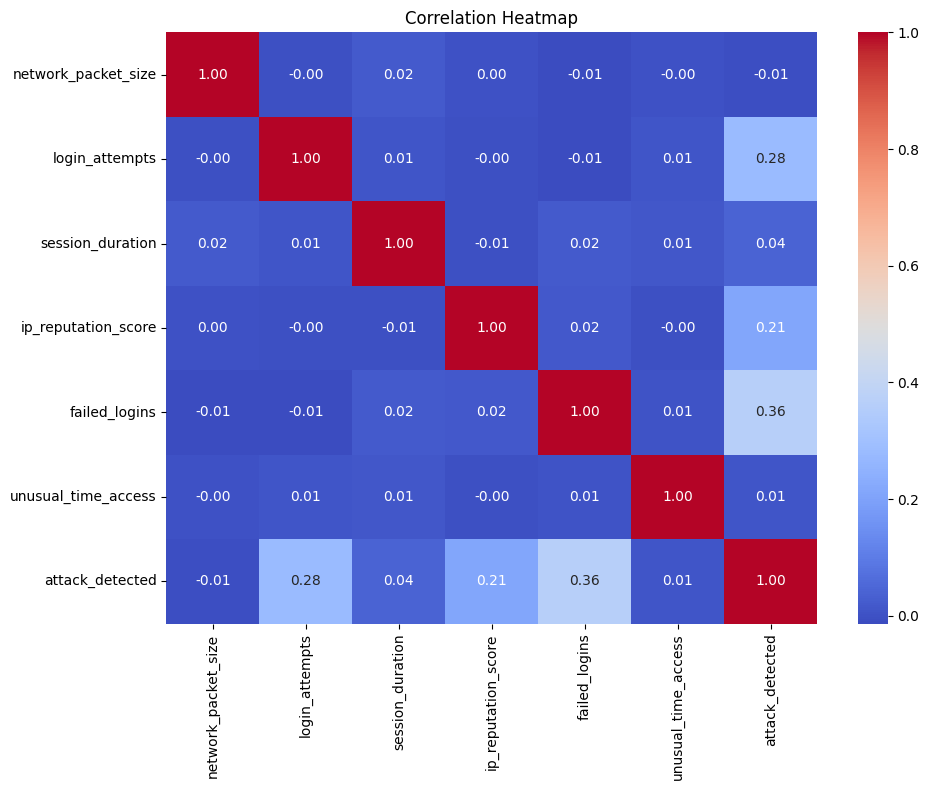

In [ ]:
# Visual 1: Correlation Heatmap (only if 4 or more numeric columns are available)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric data for a correlation heatmap.')

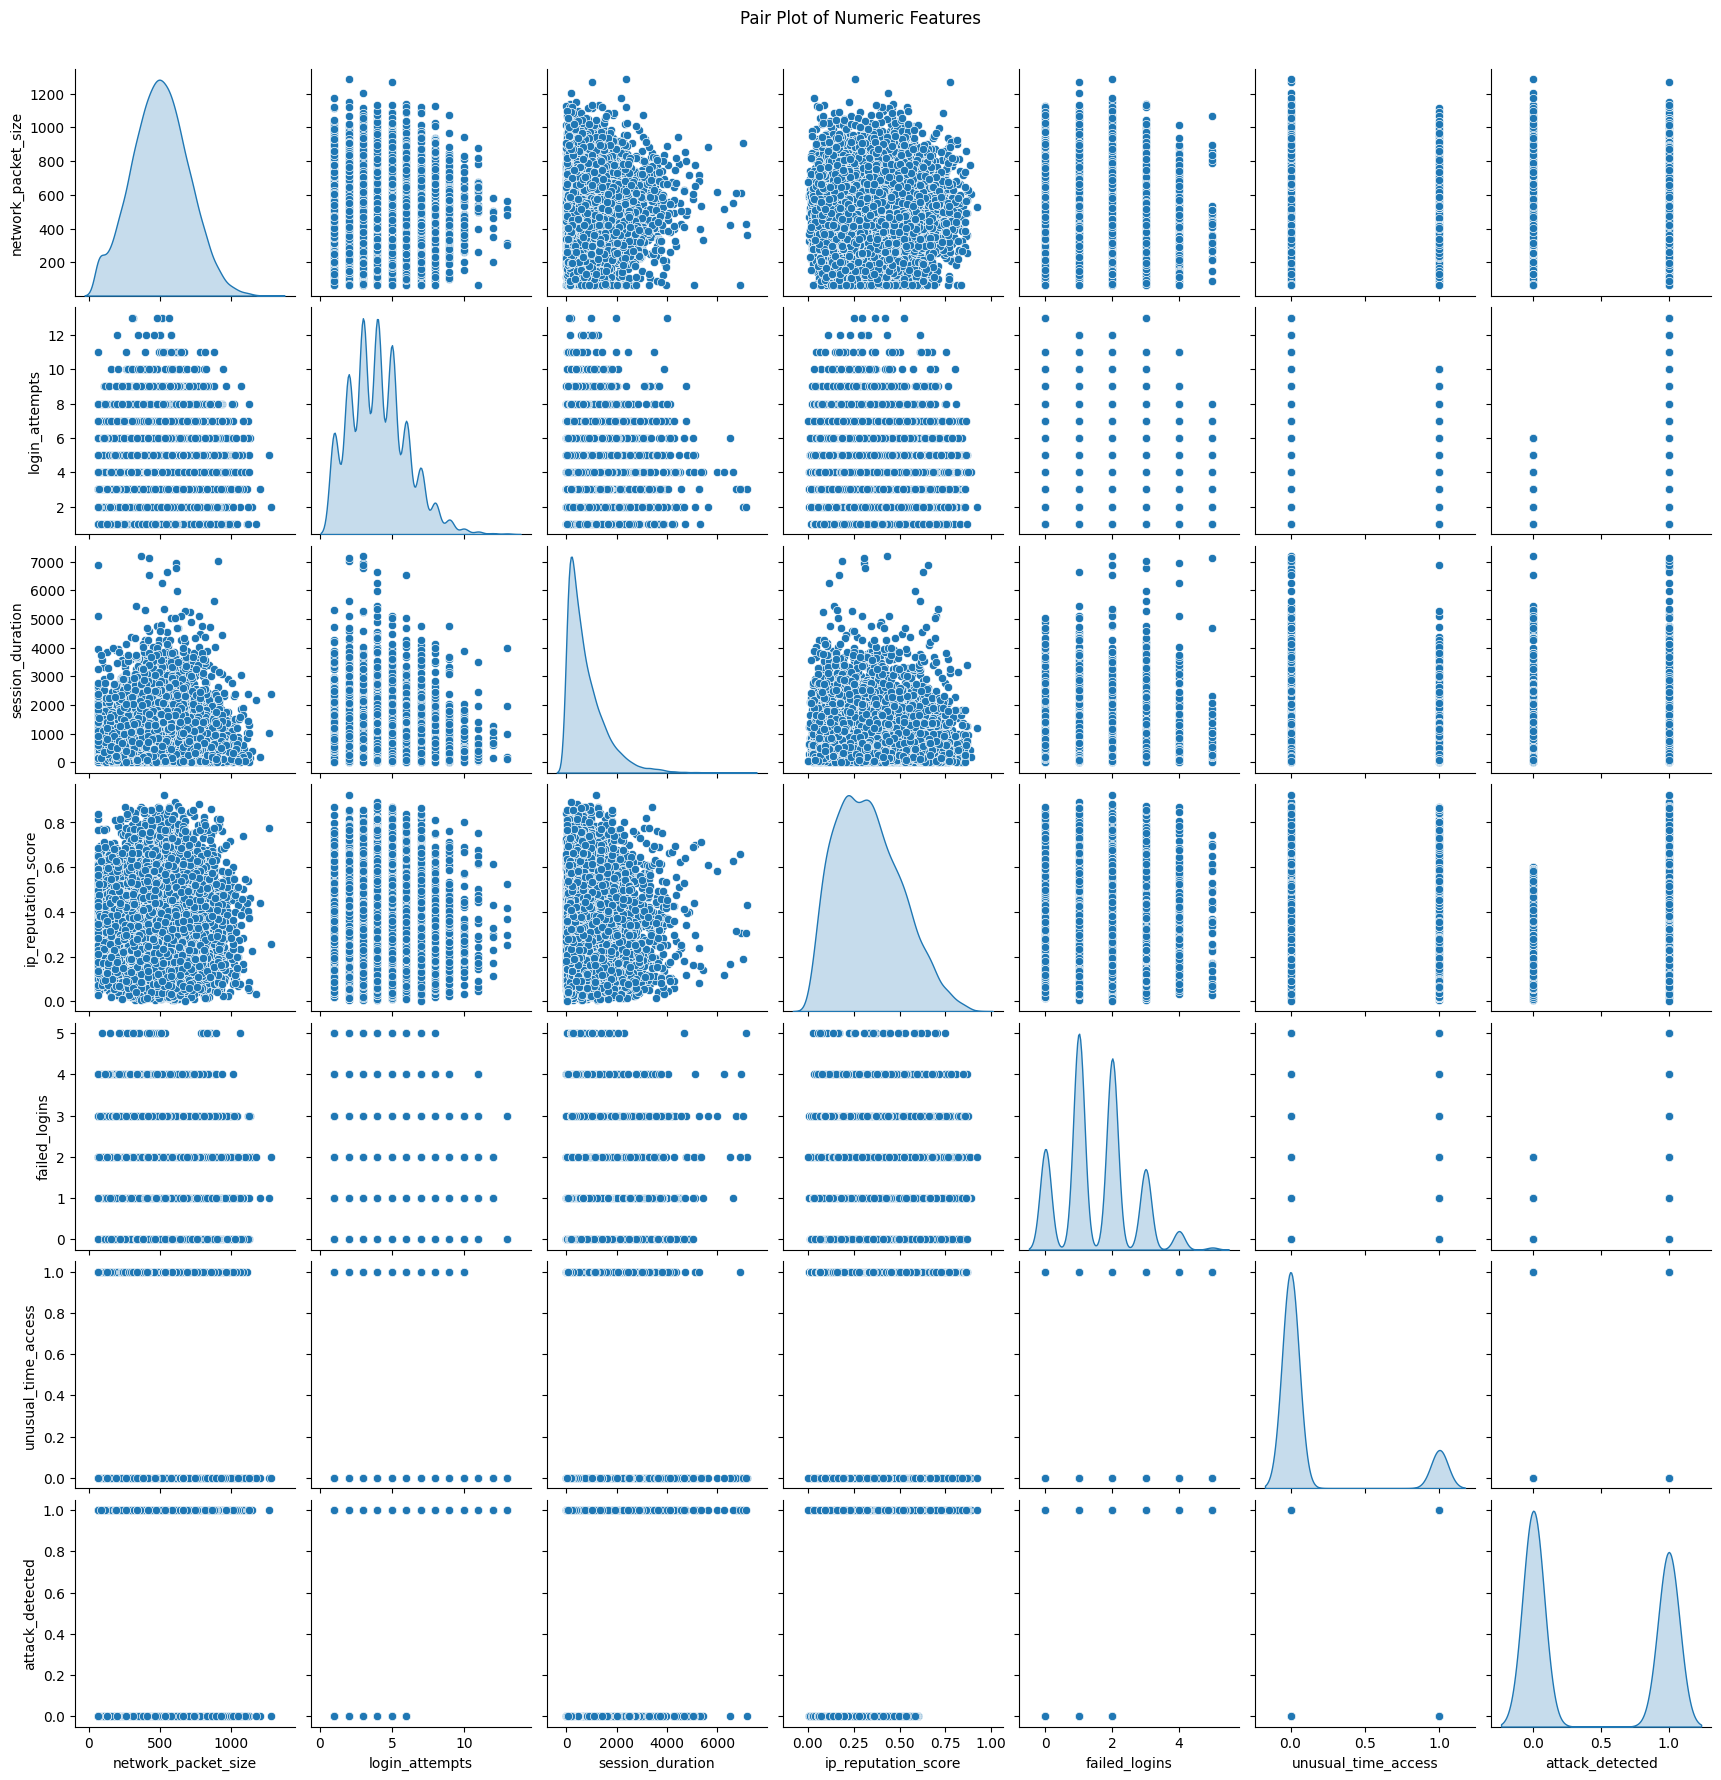

In [ ]:
# Visual 2: Pair Plot for a quick multi-dimensional view
sns.pairplot(numeric_df, diag_kind='kde')
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

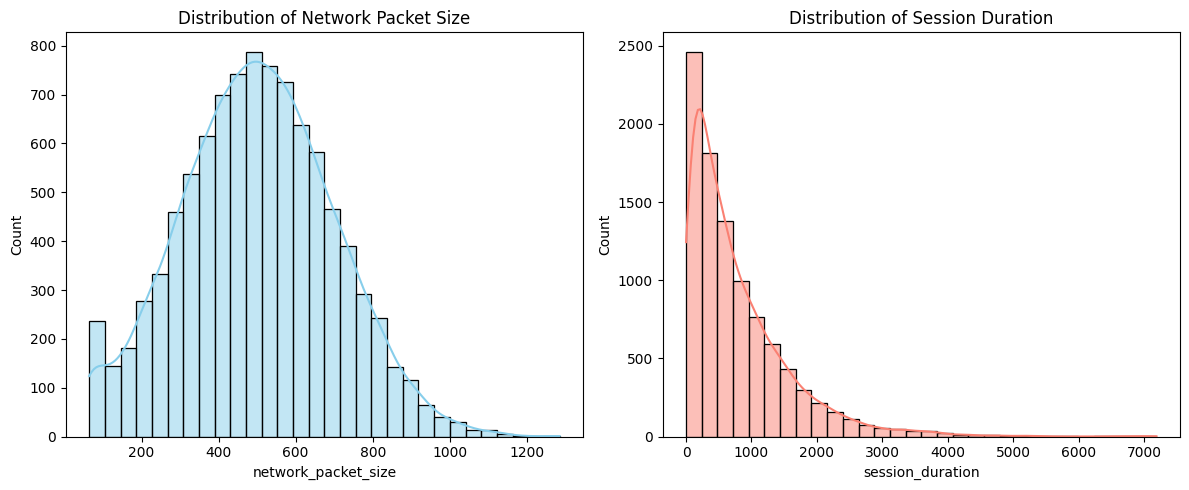

In [ ]:
# Visual 3: Histograms of network packet size and session duration
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['network_packet_size'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Network Packet Size')

plt.subplot(1, 2, 2)
sns.histplot(df['session_duration'], kde=True, bins=30, color='salmon')
plt.title('Distribution of Session Duration')

plt.tight_layout()
plt.show()

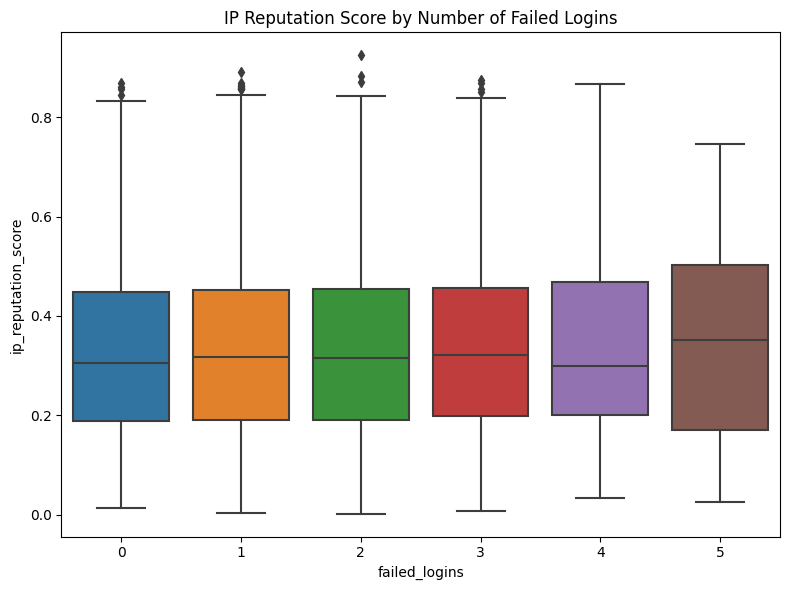

In [ ]:
# Visual 4: Box Plot of ip_reputation_score vs. failed_logins
plt.figure(figsize=(8, 6))
sns.boxplot(x='failed_logins', y='ip_reputation_score', data=df)
plt.title('IP Reputation Score by Number of Failed Logins')
plt.tight_layout()
plt.show()

## Predictive Modeling


Prediction Accuracy: 0.90


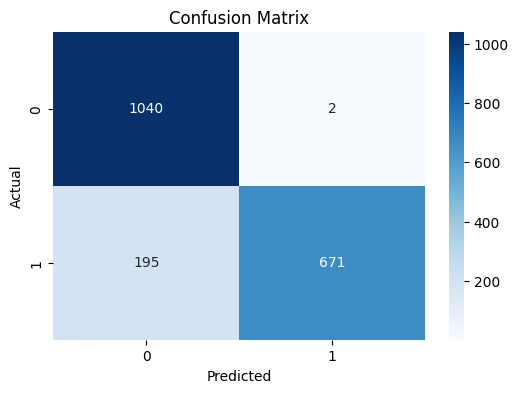

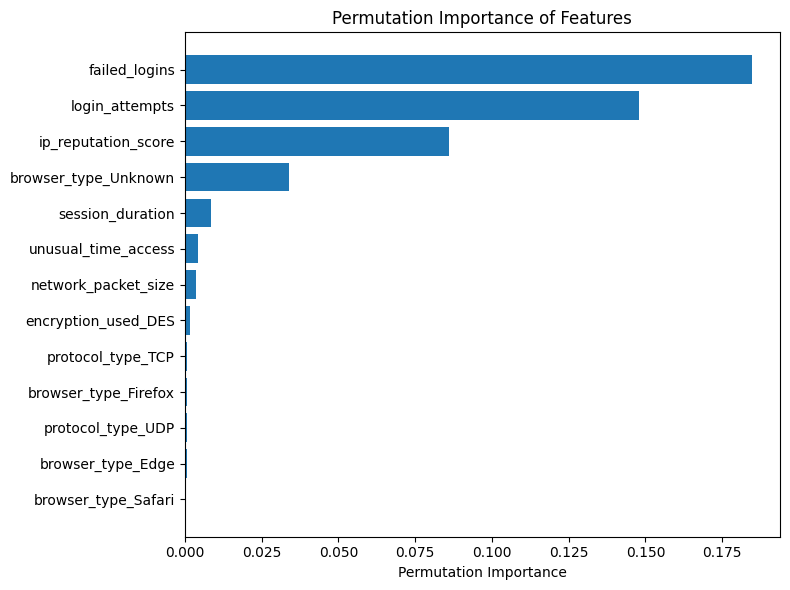

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1042
           1       1.00      0.77      0.87       866

    accuracy                           0.90      1908
   macro avg       0.92      0.89      0.89      1908
weighted avg       0.91      0.90      0.89      1908



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

# Define X and y
if 'attack_detected' not in df.columns:
    raise ValueError('Target variable "attack_detected" not found in the dataset.')

X = df.drop('attack_detected', axis=1)
y = df['attack_detected']

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the RandomForest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test data
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Prediction Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Permutation Importance
perm_importance = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(8, 6))
plt.barh(np.array(X.columns)[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('Permutation Importance of Features')
plt.tight_layout()
plt.show()

# Additional detailed classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))